In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('simulation_results_combined.csv')

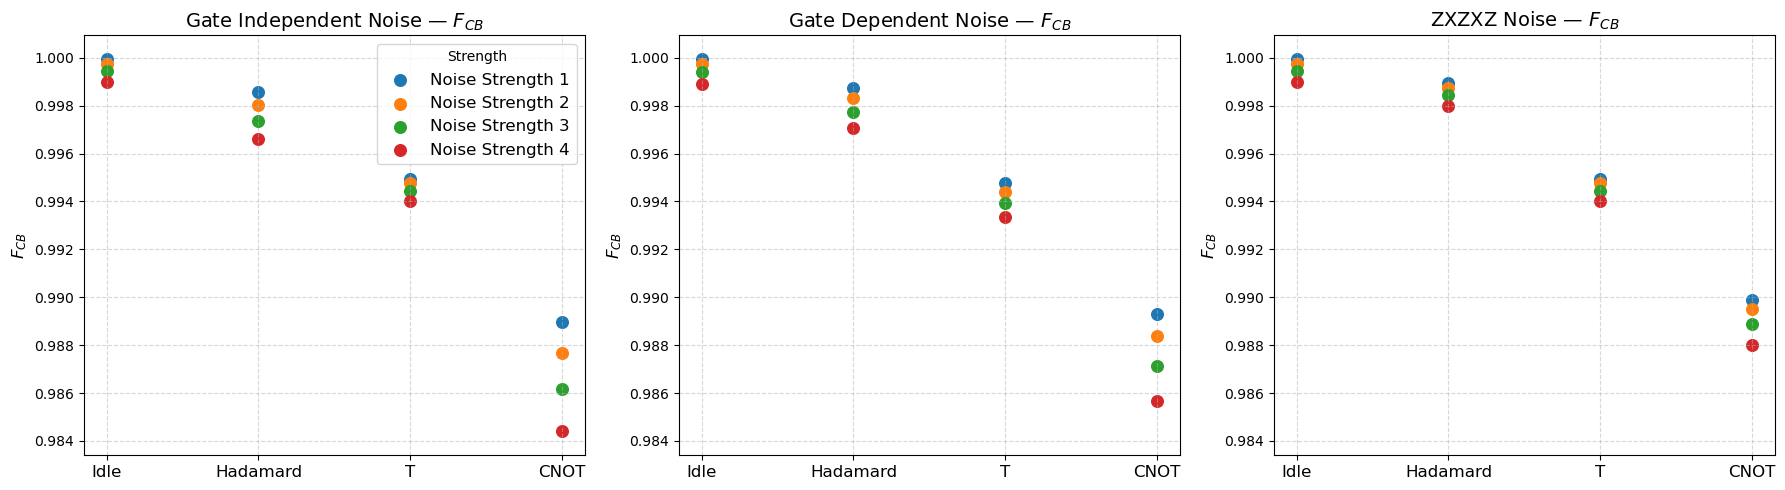

In [6]:
# Remap gate names for all plots
gate_name_map = {
    "Gate.id": "Idle",
    "Gate.h": "Hadamard",
    "Gate.t": "T",
    "Gate.cx": "CNOT",
}
df["Gate_pretty"] = df["Gate"].map(gate_name_map).fillna(df["Gate"])
gates = ["Idle", "Hadamard", "T", "CNOT"]

# Remap model names for titles
model_name_map = {
    "Gate_Independent": "Gate Independent Noise",
    "Gate_Dependent": "Gate Dependent Noise",
    "ZXZXZ": "ZXZXZ Noise",
    "ZXZXZ_Tilted": "Tilted ZXZXZ Noise",
}
df["Model_pretty"] = df["Error_Model"].map(model_name_map).fillna(df["Error_Model"])

# Filter out Tilted ZXZXZ
df_filtered = df[df["Error_Model"] != "ZXZXZ_Tilted"]
models = [m for m in df_filtered["Error_Model"].unique() if m != "ZXZXZ_Tilted"]

# Compute global y-limits for F_CB across all data
global_min = df_filtered["F_CB"].min()-0.001
global_max = df_filtered["F_CB"].max()+0.001  # small padding

# Make figure 1 row x 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, model in zip(axes.flatten(), models):
    sub = df_filtered[df_filtered["Error_Model"] == model]
    model_pretty = sub["Model_pretty"].iloc[0]
    for strength in sorted(sub["Strength"].unique()):
        ss = sub[sub["Strength"] == strength].set_index("Gate_pretty").loc[gates]
        x = np.arange(len(gates))
        ax.scatter(x, ss["F_CB"], label=f"Noise Strength {strength}", s=70)
    ax.set_title(f"{model_pretty} — $F_{{CB}}$", fontsize=14)
    ax.set_xticks(np.arange(len(gates)))
    ax.set_xticklabels(gates, rotation=0, fontsize=12)
    ax.set_ylim(global_min, global_max)
    ax.set_ylabel("$F_{CB}$", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)

# Put legend on the last subplot
axes[0].legend(title="Strength", fontsize=12, loc = 'best')
    
plt.tight_layout()
plt.show()

/var/folders/wz/lbx10qps1tdc1npmd3kbq2t00000gn/T/ipykernel_5602/1954633074.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Delta_est"] = df_filtered["F_CB"] - df_filtered["F_CB_hat"]


/var/folders/wz/lbx10qps1tdc1npmd3kbq2t00000gn/T/ipykernel_5602/1954633074.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Delta_est"] = df_filtered["F_CB"] - df_filtered["F_CB_hat"]


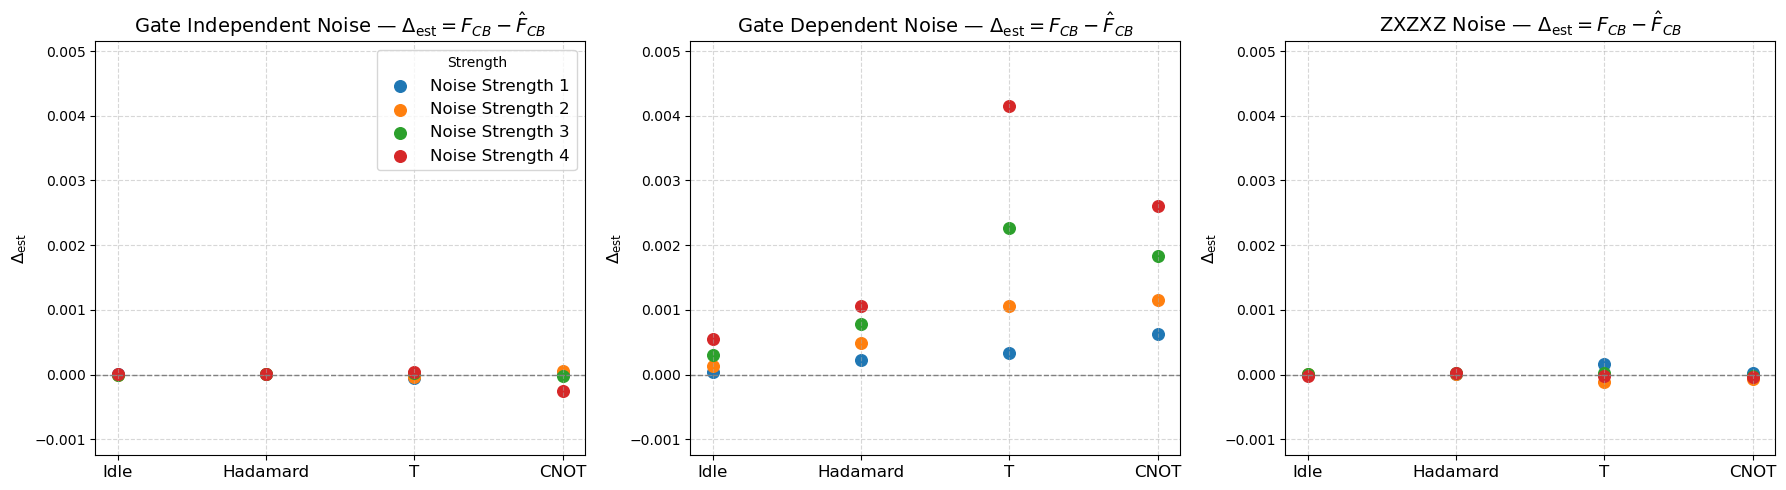

In [7]:
# ---------- Plot 2: Estimation gap Δ_est = F_CB - F_CB_hat vs Gate ----------

df_filtered["Delta_est"] = df_filtered["F_CB"] - df_filtered["F_CB_hat"]

global_min_gap = df_filtered["Delta_est"].min()
global_max_gap = df_filtered["Delta_est"].max()
pad = 0.001
ymin_gap = global_min_gap - pad
ymax_gap = global_max_gap + pad

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, model in zip(axes.flatten(), models):
    sub = df_filtered[df_filtered["Error_Model"] == model]
    model_pretty = sub["Model_pretty"].iloc[0]
    for strength in sorted(sub["Strength"].unique()):
        ss = sub[sub["Strength"] == strength].set_index("Gate_pretty").loc[gates]
        x = np.arange(len(gates))
        ax.scatter(x, ss["Delta_est"], label=f"Noise Strength {strength}", s=70)
    ax.set_title(f"{model_pretty} — $\\Delta_{{\\mathrm{{est}}}} = F_{{CB}} - \\hat F_{{CB}}$", fontsize=14)
    ax.set_xticks(np.arange(len(gates)))
    ax.set_xticklabels(gates, rotation=0, fontsize=12)
    ax.set_ylim(ymin_gap, ymax_gap)
    ax.set_ylabel("$\\Delta_{\\mathrm{est}}$", fontsize=12)
    ax.axhline(0.0, color='gray', linestyle='--', linewidth=1)
    ax.grid(True, linestyle='--', alpha=0.5)

axes[0].legend(title="Strength", fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/wz/lbx10qps1tdc1npmd3kbq2t00000gn/T/ipykernel_5602/4182530347.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Delta_gauge"] = df_filtered["F_CB"] - df_filtered["F_SCG"]


/var/folders/wz/lbx10qps1tdc1npmd3kbq2t00000gn/T/ipykernel_5602/4182530347.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Delta_gauge"] = df_filtered["F_CB"] - df_filtered["F_SCG"]


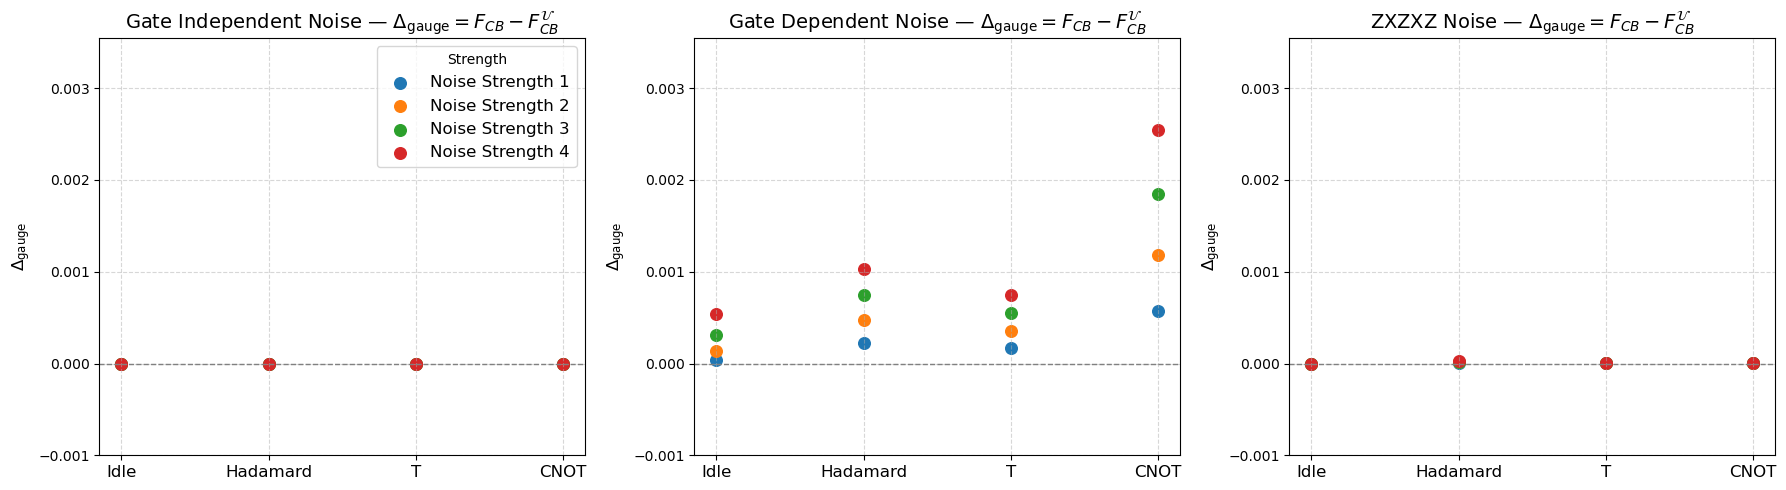

In [12]:

# ---------- Plot 3: Gauge correction gap Δ_gauge = F_CB - F_SCG vs Gate ----------

df_filtered["Delta_gauge"] = df_filtered["F_CB"] - df_filtered["F_SCG"]

global_min_ggap = df_filtered["Delta_gauge"].min()
global_max_ggap = df_filtered["Delta_gauge"].max()
pad_g = 0.001
ymin_ggap = global_min_ggap - pad_g
ymax_ggap = global_max_ggap + pad_g

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, model in zip(axes.flatten(), models):
    sub = df_filtered[df_filtered["Error_Model"] == model]
    model_pretty = sub["Model_pretty"].iloc[0]
    for strength in sorted(sub["Strength"].unique()):
        ss = sub[sub["Strength"] == strength].set_index("Gate_pretty").loc[gates]
        x = np.arange(len(gates))
        ax.scatter(x, ss["Delta_gauge"], label=f"Noise Strength {strength}", s=70)
    ax.set_title(f"{model_pretty} — $\\Delta_{{\\mathrm{{gauge}}}} = F_{{CB}} - F_{{SCG}}$", fontsize=14)
    ax.set_xticks(np.arange(len(gates)))
    ax.set_xticklabels(gates, rotation=0, fontsize=12)
    ax.set_ylim(ymin_ggap, ymax_ggap)
    ax.set_ylabel("$\\Delta_{\\mathrm{gauge}}$", fontsize=12)
    ax.axhline(0.0, color='gray', linestyle='--', linewidth=1)
    ax.grid(True, linestyle='--', alpha=0.5)

axes[0].legend(title="Strength", fontsize=12, loc = 'best')
plt.tight_layout()
plt.show()

/var/folders/wz/lbx10qps1tdc1npmd3kbq2t00000gn/T/ipykernel_5602/1410416661.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Delta_est"] = df_filtered["F_CB"] - df_filtered["F_CB_hat"]
/var/folders/wz/lbx10qps1tdc1npmd3kbq2t00000gn/T/ipykernel_5602/1410416661.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Gauge_Infidelity'] = 1-df_filtered['Gauge_Fidelity']


/var/folders/wz/lbx10qps1tdc1npmd3kbq2t00000gn/T/ipykernel_5602/1410416661.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Delta_est"] = df_filtered["F_CB"] - df_filtered["F_CB_hat"]
/var/folders/wz/lbx10qps1tdc1npmd3kbq2t00000gn/T/ipykernel_5602/1410416661.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Gauge_Infidelity'] = 1-df_filtered['Gauge_Fidelity']


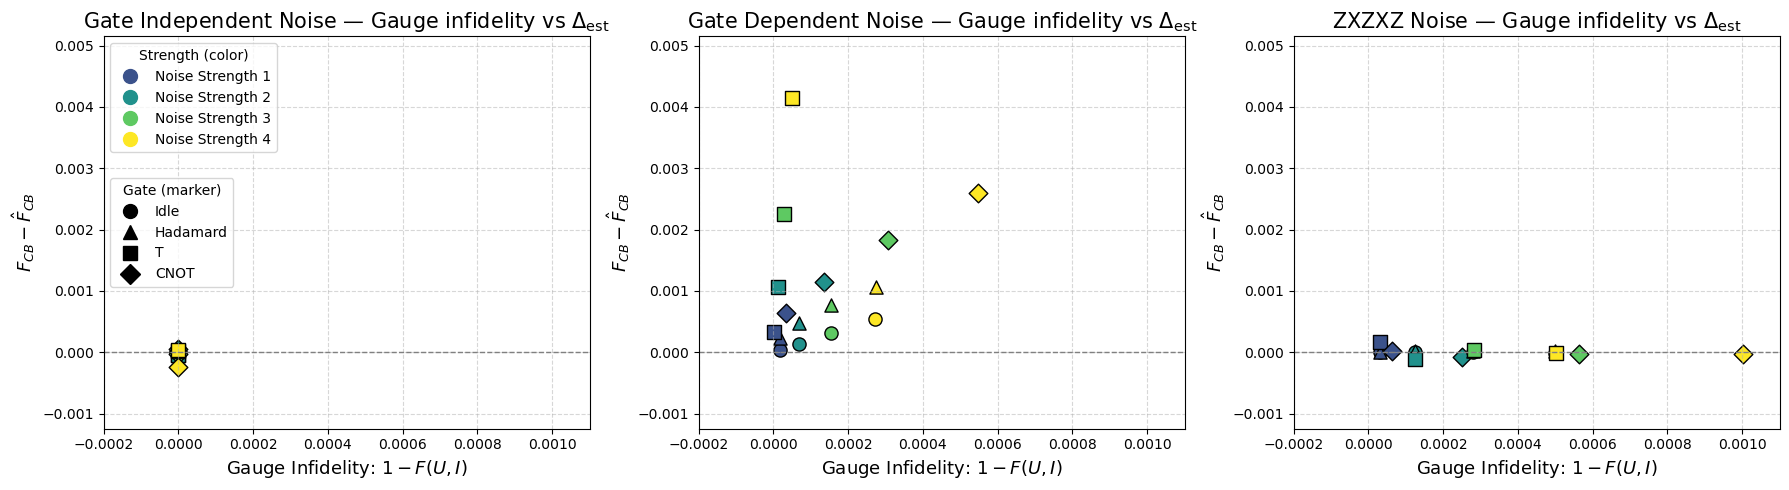

In [10]:
# ---------- Plot 4: Gauge Fidelity vs Estimation gap, per model ----------

# Recompute gaps
df_filtered["Delta_est"] = df_filtered["F_CB"] - df_filtered["F_CB_hat"]
df_filtered['Gauge_Infidelity'] = 1-df_filtered['Gauge_Fidelity']

# Global limits for Delta_est
pad_y = 0.001
ymin_gap = df_filtered["Delta_est"].min() - pad_y
ymax_gap = df_filtered["Delta_est"].max() + pad_y

# Gauge fidelity x-limits
pad_x = 0.0001
xmin_gf = df_filtered["Gauge_Infidelity"].min() - pad_x
xmax_gf = min(1.0, df_filtered["Gauge_Infidelity"].max() + pad_x)

# Color map by strength
strengths = sorted(df_filtered["Strength"].unique())
color_map = {s: plt.cm.viridis((i + 1) / len(strengths)) for i, s in enumerate(strengths)}

# Marker map by gate
marker_map = {
    "Idle": "o",
    "Hadamard": "^",
    "T": "s",
    "CNOT": "D",
}

# Plot: Gauge Fidelity vs Delta_est, with separate legends for strength and gate
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, model in zip(axes.flatten(), models):
    sub = df_filtered[df_filtered["Error_Model"] == model]
    model_pretty = sub["Model_pretty"].iloc[0]

    for strength in strengths:
        for gate in gates:
            row = sub[(sub["Strength"] == strength) & (sub["Gate_pretty"] == gate)]
            if row.empty:
                continue

            gf = row["Gauge_Infidelity"].iloc[0]
            de = row["Delta_est"].iloc[0]

            ax.scatter(
                gf,
                de,
                s=90,
                color=color_map[strength],
                marker=marker_map[gate],
                edgecolor="black"
            )

    ax.set_title(f"{model_pretty} — Gauge infidelity vs $\\Delta_{{\\mathrm{{est}}}}$", fontsize=15)
    ax.set_xlabel("Gauge Infidelity: $1- F(U,I)$", fontsize=13)
    ax.set_ylabel("$F_{CB} - \\hat F_{CB}$", fontsize=13)
    ax.axhline(0.0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlim(xmin_gf-0.0001, xmax_gf)
    ax.set_ylim(ymin_gap, ymax_gap)

    # FIX OFFSET BEHAVIOR
    ax.ticklabel_format(useOffset=False, style='plain')

    ax.grid(True, linestyle="--", alpha=0.5)

# Strength legend (color)
strength_handles = [
    plt.Line2D([0], [0], marker='o', color=color_map[s], linestyle='', markersize=10)
    for s in strengths
]
strength_labels = [f"Noise Strength {s}" for s in strengths]

strength_legend = axes[0].legend(
    strength_handles, strength_labels,
    title="Strength (color)", fontsize=10,
    loc="upper left"
)
axes[0].add_artist(strength_legend)

# Gate legend (marker)
gate_handles = [
    plt.Line2D([0], [0], marker=marker_map[g], color='black', linestyle='', markersize=10)
    for g in gates
]
gate_labels = gates

axes[0].legend(
    gate_handles, gate_labels,
    title="Gate (marker)", fontsize=10,
    loc="center left"
)

plt.tight_layout()
plt.show()

/var/folders/wz/lbx10qps1tdc1npmd3kbq2t00000gn/T/ipykernel_5602/2031821100.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Delta_est"] = df_filtered["F_CB"] - df_filtered["F_CB_hat"]
/var/folders/wz/lbx10qps1tdc1npmd3kbq2t00000gn/T/ipykernel_5602/2031821100.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Delta_gauge"] = df_filtered["F_CB"] - df_filtered["F_SCG"]


/var/folders/wz/lbx10qps1tdc1npmd3kbq2t00000gn/T/ipykernel_5602/2031821100.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Delta_est"] = df_filtered["F_CB"] - df_filtered["F_CB_hat"]
/var/folders/wz/lbx10qps1tdc1npmd3kbq2t00000gn/T/ipykernel_5602/2031821100.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Delta_gauge"] = df_filtered["F_CB"] - df_filtered["F_SCG"]


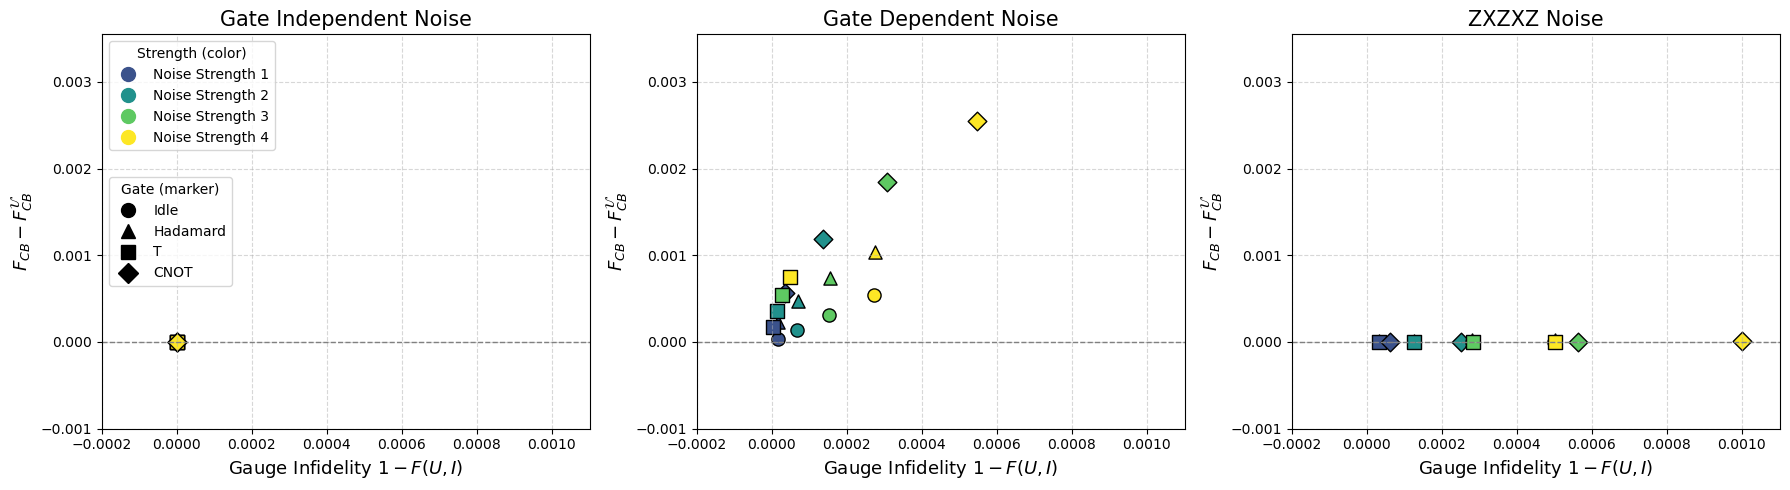

In [17]:
# Recompute gaps
df_filtered["Delta_est"] = df_filtered["F_CB"] - df_filtered["F_CB_hat"]
df_filtered["Delta_gauge"] = df_filtered["F_CB"] - df_filtered["F_SCG"]

# ---------- Plot A: Gauge Fidelity vs Δ_gauge = F_CB - F_SCG ----------

# Global limits for Delta_gauge
pad_y = 0.001
ymin_ggap = df_filtered["Delta_gauge"].min() - pad_y
ymax_ggap = df_filtered["Delta_gauge"].max() + pad_y

# Gauge fidelity x-limits
pad_x = 0.0001
xmin_gf = df_filtered["Gauge_Infidelity"].min() - pad_x
xmax_gf = min(1.0, df_filtered["Gauge_Infidelity"].max() + pad_x)

# Color map by strength (same as before)
color_map = {s: plt.cm.viridis((i + 1) / len(strengths)) for i, s in enumerate(strengths)}

# Marker map by gate
marker_map = {
    "Idle": "o",
    "Hadamard": "^",
    "T": "s",
    "CNOT": "D",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, model in zip(axes.flatten(), models):
    sub = df_filtered[df_filtered["Error_Model"] == model]
    model_pretty = sub["Model_pretty"].iloc[0]

    for strength in strengths:
        for gate in gates:
            row = sub[(sub["Strength"] == strength) & (sub["Gate_pretty"] == gate)]
            if row.empty:
                continue

            gf = row["Gauge_Infidelity"].iloc[0]
            dg = row["Delta_gauge"].iloc[0]

            ax.scatter(
                gf,
                dg,
                s=90,
                color=color_map[strength],
                marker=marker_map[gate],
                edgecolor="black"
            )

    ax.set_title(f"{model_pretty}", fontsize=15)
    ax.set_xlabel("Gauge Infidelity $1-F(U,I)$", fontsize=13)
    ax.set_ylabel("$F_{CB} - F_{SCG}$", fontsize=13)
    ax.axhline(0.0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlim(xmin_gf-0.0001, xmax_gf)
    ax.set_ylim(ymin_ggap, ymax_ggap)
    ax.ticklabel_format(useOffset=False, style='plain')
    ax.grid(True, linestyle="--", alpha=0.5)

# Strength legend (color)
strength_handles = [
    plt.Line2D([0], [0], marker='o', color=color_map[s], linestyle='', markersize=10)
    for s in strengths
]
strength_labels = [f"Noise Strength {s}" for s in strengths]

strength_legend = axes[0].legend(
    strength_handles, strength_labels,
    title="Strength (color)", fontsize=10,
    loc="upper left"
)
axes[0].add_artist(strength_legend)

# Gate legend (marker)
gate_handles = [
    plt.Line2D([0], [0], marker=marker_map[g], color='black', linestyle='', markersize=10)
    for g in gates
]
gate_labels = gates

axes[0].legend(
    gate_handles, gate_labels,
    title="Gate (marker)", fontsize=10,
    loc="center left"
)

plt.tight_layout()
plt.show()

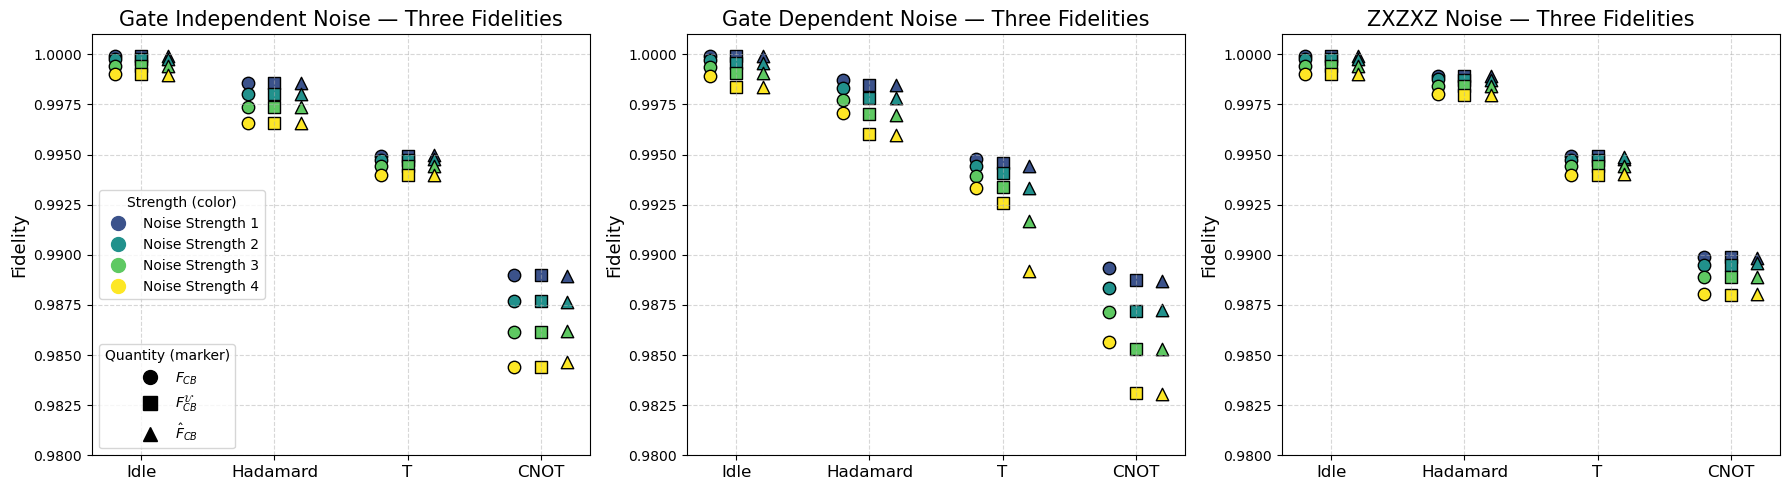

In [19]:
# y-limits across all three fidelities
all_fids = pd.concat([df_filtered["F_CB"], df_filtered["F_SCG"], df_filtered["F_CB_hat"]])

# Color map by strength
color_map = {s: plt.cm.viridis((i + 1) / len(strengths)) for i, s in enumerate(strengths)}

# Marker map by fidelity type
marker_map = {
    "F_CB": "o",
    "F_SCG": "s",
    "F_CB_hat": "^",
}

offsets = {
    "F_CB": -0.2,
    "F_SCG": 0.0,
    "F_CB_hat": 0.2
}

# x positions for gates
x_positions = np.arange(len(gates))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, model in zip(axes.flatten(), models):
    sub = df_filtered[df_filtered["Error_Model"] == model]
    model_pretty = sub["Model_pretty"].iloc[0]

    for strength in strengths:
        sub_s = sub[sub["Strength"] == strength].set_index("Gate_pretty").loc[gates]

        for j, gate in enumerate(gates):
            row = sub_s.loc[gate]

            x = x_positions[j]

            # Plot three fidelities with horizontal offsets so they are side-by-side
            for fid in ["F_CB", "F_SCG", "F_CB_hat"]:
                ax.scatter(
                    x + offsets[fid],
                    row[fid],
                    s=80,
                    color=color_map[strength],
                    marker=marker_map[fid],
                    edgecolor="black"
                )

    ax.set_title(f"{model_pretty} — Three Fidelities", fontsize=15)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(gates, rotation=0, fontsize=12)
    ax.set_ylabel("Fidelity", fontsize=13)
    ax.set_ylim(0.98, 1.001)
    ax.grid(True, linestyle="--", alpha=0.5)

# Legends
strength_handles = [
    plt.Line2D([0], [0], marker='o', color=color_map[s], linestyle='', markersize=10)
    for s in strengths
]
strength_labels = [f"Noise Strength {s}" for s in strengths]

strength_legend = axes[0].legend(
    strength_handles, strength_labels,
    title="Strength (color)", fontsize=10,
    loc="center left"
)
axes[0].add_artist(strength_legend)

fid_handles = [
    plt.Line2D([0], [0], marker=marker_map[key], color='black', linestyle='', markersize=10)
    for key in ["F_CB", "F_SCG", "F_CB_hat"]
]
fid_labels = [r"$F_{CB}$", r"$F_{SCG}$", r"$\hat F_{CB}$"]

axes[0].legend(
    fid_handles, fid_labels,
    title="Quantity (marker)", fontsize=10,
    loc="lower left"
)

plt.tight_layout()
plt.show()

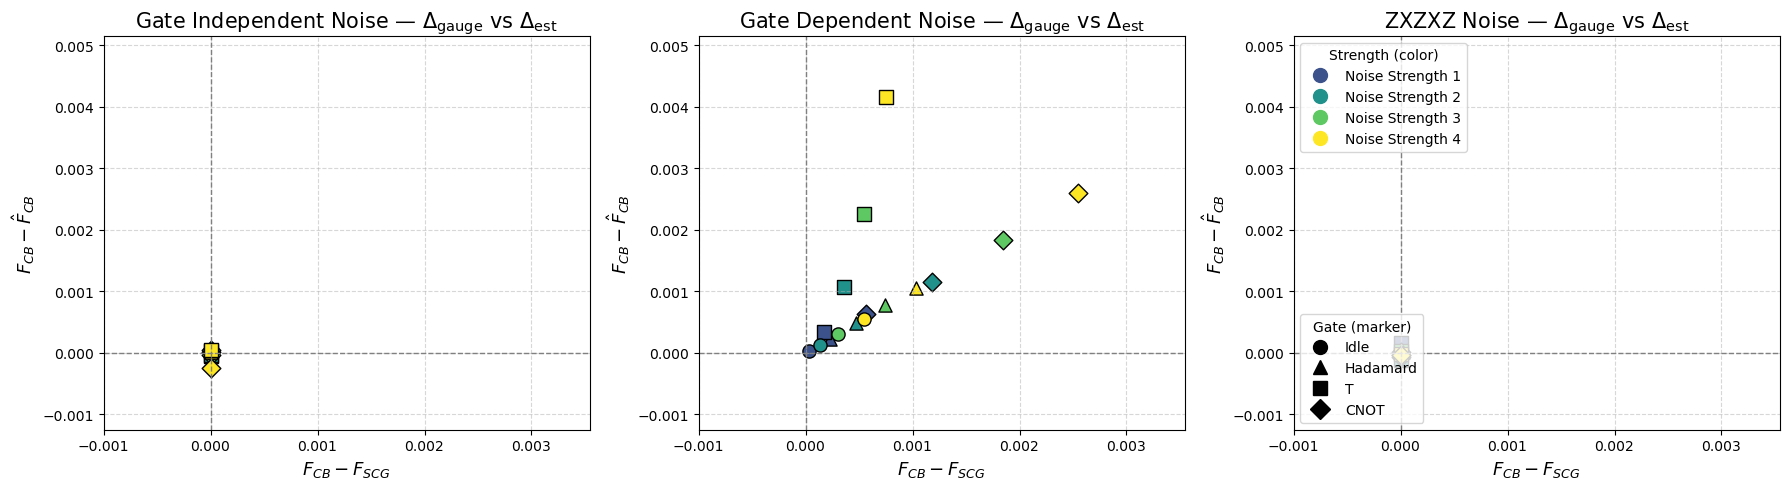

In [30]:
# Global limits for both gaps (for nicer comparison)
pad = 0.001
xmin = float(df_filtered["Delta_gauge"].min() - pad)
xmax = float(df_filtered["Delta_gauge"].max() + pad)
ymin = float(df_filtered["Delta_est"].min() - pad)
ymax = float(df_filtered["Delta_est"].max() + pad)

# Set up color-by-strength and marker-by-gate
color_map = {s: plt.cm.viridis((i + 1) / len(strengths)) for i, s in enumerate(strengths)}
marker_map = {
    "Idle": "o",
    "Hadamard": "^",
    "T": "s",
    "CNOT": "D",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, model in zip(axes.flatten(), models):
    sub = df_filtered[df_filtered["Error_Model"] == model]
    model_pretty = sub["Model_pretty"].iloc[0]

    for strength in strengths:
        for gate in gates:
            row = sub[(sub["Strength"] == strength) & (sub["Gate_pretty"] == gate)]
            if row.empty:
                continue
            dx = row["Delta_gauge"].iloc[0]
            dy = row["Delta_est"].iloc[0]

            ax.scatter(
                dx,
                dy,
                s=90,
                color=color_map[strength],
                marker=marker_map[gate],
                edgecolor="black"
            )

    ax.set_title(f"{model_pretty} — $\\Delta_{{\\mathrm{{gauge}}}}$ vs $\\Delta_{{\\mathrm{{est}}}}$", fontsize=15)
    ax.set_xlabel("$F_{CB} - F_{SCG}$", fontsize=13)
    ax.set_ylabel("$F_{CB} - \\hat F_{CB}$", fontsize=13)
    ax.axhline(0.0, color="gray", linestyle="--", linewidth=1)
    ax.axvline(0.0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.ticklabel_format(useOffset=False, style='plain')

# Legends: strength (color) and gate (marker)
strength_handles = [
    plt.Line2D([0], [0], marker='o', color=color_map[s], linestyle='', markersize=10)
    for s in strengths
]
strength_labels = [f"Noise Strength {s}" for s in strengths]
strength_legend = axes[2].legend(
    strength_handles, strength_labels,
    title="Strength (color)", fontsize=10,
    loc="upper left"
)
axes[2].add_artist(strength_legend)

gate_handles = [
    plt.Line2D([0], [0], marker=marker_map[g], color='black', linestyle='', markersize=10)
    for g in gates
]
gate_labels = gates
axes[2].legend(
    gate_handles, gate_labels,
    title="Gate (marker)", fontsize=10,
    loc="lower left"
)

plt.tight_layout()
plt.show()

/var/folders/wz/lbx10qps1tdc1npmd3kbq2t00000gn/T/ipykernel_22025/3242722470.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Delta1"] = df_filtered["F_CB"] - df_filtered["F_CB_hat"]      # F_CB - F_CB_hat
/var/folders/wz/lbx10qps1tdc1npmd3kbq2t00000gn/T/ipykernel_22025/3242722470.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Delta2"] = df_filtered["F_CB"] - df_filtered["F_SCG"]         # F_CB - F_SCG
/var/folders/wz/lbx10qps1tdc1npmd3kbq2t00000gn/T/ipykernel_22025/32427224

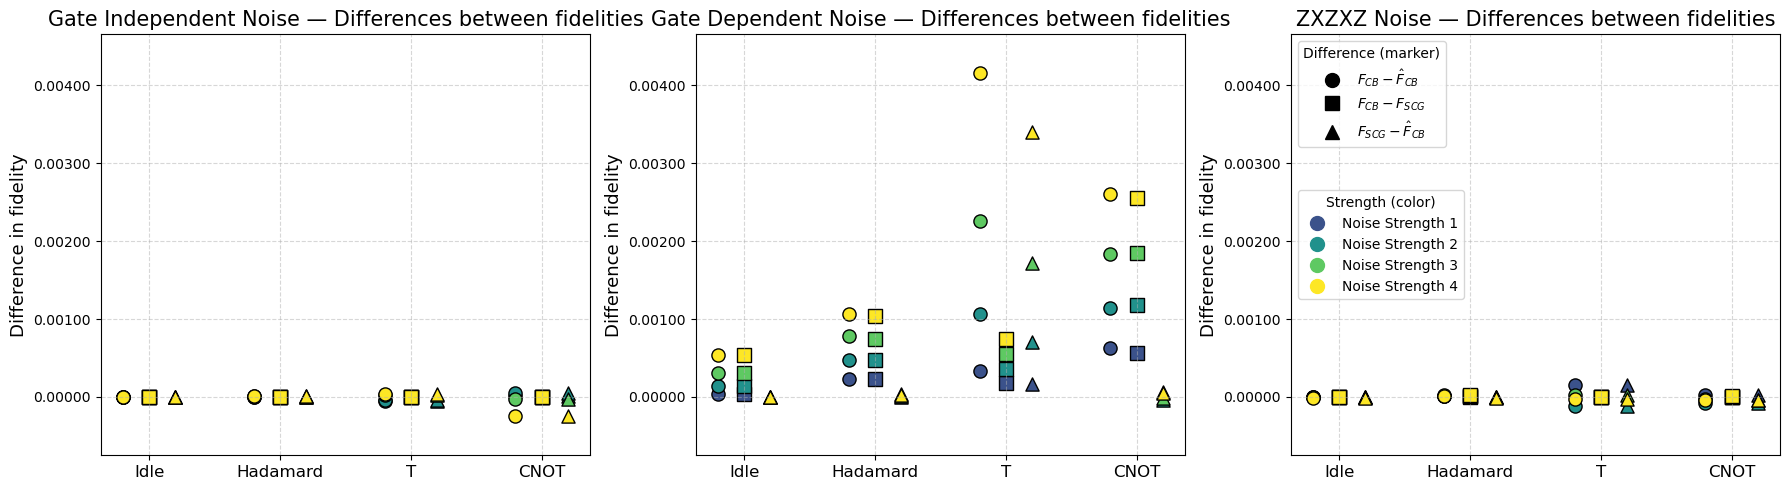

In [31]:
from matplotlib.ticker import FuncFormatter
# --- Compute the three differences ---
df_filtered["Delta1"] = df_filtered["F_CB"] - df_filtered["F_CB_hat"]      # F_CB - F_CB_hat
df_filtered["Delta2"] = df_filtered["F_CB"] - df_filtered["F_SCG"]         # F_CB - F_SCG
df_filtered["Delta3"] = df_filtered["F_SCG"] - df_filtered["F_CB_hat"]     # F_SCG - F_CB_hat

# Color map by strength
color_map = {s: plt.cm.viridis((i + 1) / len(strengths)) for i, s in enumerate(strengths)}

# Marker map for the 3 difference types
marker_map = {
    "Delta1": "o",
    "Delta2": "s",
    "Delta3": "^",
}

# horizontal offsets 
offsets = {
    "Delta1": -0.2,
    "Delta2": 0.0,
    "Delta3": 0.2
}

x_positions = np.arange(len(gates))

# global y-limits
all_diffs = pd.concat([df_filtered["Delta1"], df_filtered["Delta2"], df_filtered["Delta3"]])
pad = 0.0005
ymin = float(all_diffs.min() - pad)
ymax = float(all_diffs.max() + pad)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, model in zip(axes.flatten(), models):
    sub = df_filtered[df_filtered["Error_Model"] == model]
    model_pretty = sub["Model_pretty"].iloc[0]

    for strength in strengths:
        sub_s = sub[sub["Strength"] == strength].set_index("Gate_pretty").loc[gates]

        for j, gate in enumerate(gates):
            row = sub_s.loc[gate]
            x = x_positions[j]

            for diff in ["Delta1", "Delta2", "Delta3"]:
                ax.scatter(
                    x + offsets[diff],
                    row[diff],
                    s=90,
                    color=color_map[strength],
                    marker=marker_map[diff],
                    edgecolor="black"
                )

    ax.set_title(f"{model_pretty} — Differences between fidelities", fontsize=15)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(gates, rotation=0, fontsize=12)
    ax.set_ylabel("Difference in fidelity", fontsize=13)
    ax.set_ylim(ymin, ymax)
    ax.grid(True, linestyle="--", alpha=0.5)

    # Clean numeric formatting on y-axis
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.5f}"))

# Legends

# Strength legend (color)
strength_handles = [
    plt.Line2D([0], [0], marker='o', color=color_map[s], linestyle='', markersize=10)
    for s in strengths
]
strength_labels = [f"Noise Strength {s}" for s in strengths]
strength_legend = axes[2].legend(
    strength_handles, strength_labels,
    title="Strength (color)", fontsize=10,
    loc="center left"
)
axes[2].add_artist(strength_legend)

# Difference-type legend (marker)
diff_handles = [
    plt.Line2D([0], [0], marker=marker_map[key], color='black', linestyle='', markersize=10)
    for key in ["Delta1", "Delta2", "Delta3"]
]
diff_labels = [
    r"$F_{CB} - \hat{F}_{CB}$",
    r"$F_{CB} - F_{SCG}$",
    r"$F_{SCG} - \hat{F}_{CB}$"
]

axes[2].legend(
    diff_handles, diff_labels,
    title="Difference (marker)", fontsize=10,
    loc="upper left"
)

plt.tight_layout()
plt.show()

/var/folders/wz/lbx10qps1tdc1npmd3kbq2t00000gn/T/ipykernel_22025/499713546.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Delta1"] = df_filtered["F_CB"] - df_filtered["F_CB_hat"]
/var/folders/wz/lbx10qps1tdc1npmd3kbq2t00000gn/T/ipykernel_22025/499713546.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Gauge_Infidelity"] = 1 - df_filtered["Gauge_Fidelity"]


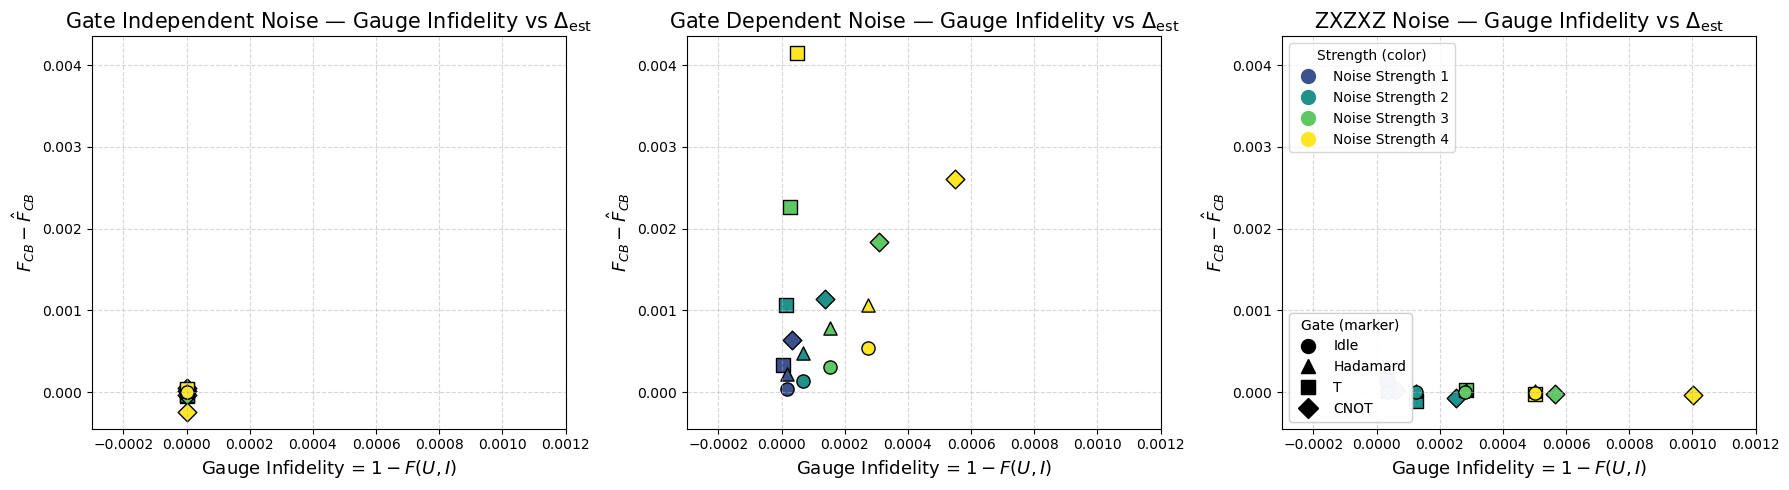

In [32]:
# Compute gaps
df_filtered["Delta1"] = df_filtered["F_CB"] - df_filtered["F_CB_hat"]
df_filtered["Gauge_Infidelity"] = 1 - df_filtered["Gauge_Fidelity"]

strengths = sorted(df_filtered["Strength"].unique())

# Color by strength
color_map = {s: plt.cm.viridis((i+1)/len(strengths)) for i, s in enumerate(strengths)}
# Marker by gate
marker_map = {"Idle": "o", "Hadamard": "^", "T": "s", "CNOT": "D"}

# Axis limits
pad = 0.0002
xmin = df_filtered["Gauge_Infidelity"].min() - pad
xmax = df_filtered["Gauge_Infidelity"].max() + pad
ymin = df_filtered["Delta1"].min() - pad
ymax = df_filtered["Delta1"].max() + pad

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model in zip(axes.flatten(), models):
    sub = df_filtered[df_filtered["Error_Model"] == model]
    model_pretty = sub["Model_pretty"].iloc[0]

    for strength in strengths:
        sub_s = sub[sub["Strength"] == strength]
        for _, row in sub_s.iterrows():
            ax.scatter(
                row["Gauge_Infidelity"],
                row["Delta1"],
                s=90,
                color=color_map[strength],
                marker=marker_map[row["Gate_pretty"]],
                edgecolor="black"
            )

    ax.set_title(f"{model_pretty} — Gauge Infidelity vs $\\Delta_{{\\mathrm{{est}}}}$", fontsize=15)
    ax.set_xlabel("Gauge Infidelity = $1 - F(U,I)$", fontsize=13)
    ax.set_ylabel(r"$F_{CB} - \hat F_{CB}$", fontsize=13)
    ax.set_xlim(xmin-0.0001, xmax)
    ax.set_ylim(ymin, ymax)
    ax.grid(True, linestyle="--", alpha=0.5)

# Strength legend
strength_handles = [
    plt.Line2D([0], [0], marker='o', color=color_map[s], linestyle='', markersize=10)
    for s in strengths
]
strength_labels = [f"Noise Strength {s}" for s in strengths]
strength_legend = axes[2].legend(
    strength_handles, strength_labels,
    title="Strength (color)", fontsize=10,
    loc="upper left"
)
axes[2].add_artist(strength_legend)

# Gate legend
gate_handles = [
    plt.Line2D([0],[0], marker=marker_map[g], color='black', linestyle='', markersize=10)
    for g in gates
]
axes[2].add_artist(
    plt.legend(
        gate_handles, gates,
        title="Gate (marker)", loc="lower left"
    )
)

plt.tight_layout()
plt.show()

/var/folders/wz/lbx10qps1tdc1npmd3kbq2t00000gn/T/ipykernel_22025/2196431553.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Gauge_Infidelity"] = 1 - df_filtered["Gauge_Fidelity"]


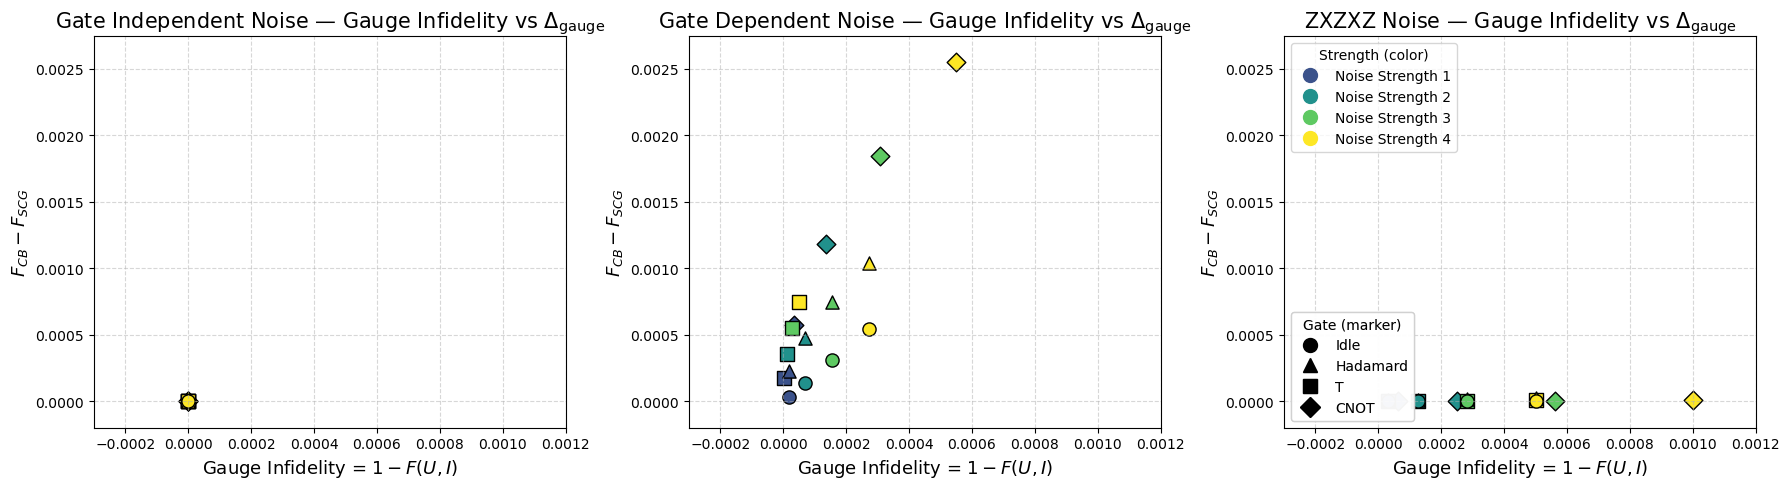

In [33]:
df_filtered["Gauge_Infidelity"] = 1 - df_filtered["Gauge_Fidelity"]

strengths = sorted(df_filtered["Strength"].unique())

# Color by strength
color_map = {s: plt.cm.viridis((i+1)/len(strengths)) for i, s in enumerate(strengths)}
# Marker by gate
marker_map = {"Idle": "o", "Hadamard": "^", "T": "s", "CNOT": "D"}

# Axis limits
pad = 0.0002
xmin = df_filtered["Gauge_Infidelity"].min() - pad
xmax = df_filtered["Gauge_Infidelity"].max() + pad
ymin = df_filtered["Delta_gauge"].min() - pad
ymax = df_filtered["Delta_gauge"].max() + pad

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model in zip(axes.flatten(), models):
    sub = df_filtered[df_filtered["Error_Model"] == model]
    model_pretty = sub["Model_pretty"].iloc[0]

    for strength in strengths:
        sub_s = sub[sub["Strength"] == strength]
        for _, row in sub_s.iterrows():
            ax.scatter(
                row["Gauge_Infidelity"],
                row["Delta_gauge"],
                s=90,
                color=color_map[strength],
                marker=marker_map[row["Gate_pretty"]],
                edgecolor="black"
            )

    ax.set_title(f"{model_pretty} — Gauge Infidelity vs $\\Delta_{{\\mathrm{{gauge}}}}$", fontsize=15)
    ax.set_xlabel("Gauge Infidelity = $1 - F(U,I)$", fontsize=13)
    ax.set_ylabel(r"$F_{CB} -  F_{SCG}$", fontsize=13)
    ax.set_xlim(xmin-0.0001, xmax)
    ax.set_ylim(ymin, ymax)
    ax.grid(True, linestyle="--", alpha=0.5)

# Strength legend
strength_handles = [
    plt.Line2D([0], [0], marker='o', color=color_map[s], linestyle='', markersize=10)
    for s in strengths
]
strength_labels = [f"Noise Strength {s}" for s in strengths]
strength_legend = axes[2].legend(
    strength_handles, strength_labels,
    title="Strength (color)", fontsize=10,
    loc="upper left"
)
axes[2].add_artist(strength_legend)

# Gate legend
gate_handles = [
    plt.Line2D([0],[0], marker=marker_map[g], color='black', linestyle='', markersize=10)
    for g in gates
]
axes[2].add_artist(
    plt.legend(
        gate_handles, gates,
        title="Gate (marker)", loc="lower left"
    )
)

plt.tight_layout()
plt.show()